# Advanced Chemical Reaction Engineering (CBE 60546)
## Homework 8
## Due December 3, 2025

Carefully and neatly document your answers. Use Jupyter/Collab for all plots. See sample code at https://github.com/wmfschneider/CBE60546/blob/main/Resources/Examples.ipynb.

# Q1. All mixed up
You have available a CSTR and a PFR of equal size that you plan to connect in series to carry out a first-order reaction:

$$\ce{A -> B}\ \ \ \ \ \ \ \ r = k C_{\ce{A}}$$

### Q1.1. Sketch the residence time distribution $p(\theta)$ you expect if the CSTR is placed in front of the PFR.

Each unit has the same volume and flowrate, so each has mean residence time  

$
\tau_\text{CSTR} = \tau_\text{PFR} = \tau, \qquad \tau_\text{tot} = 2\tau .
$

- CSTR alone: $p_\text{CSTR}(\theta) = \dfrac{1}{\tau} e^{-\theta/\tau}$
- PFR alone: $p_\text{PFR}(\theta) = \delta(\theta-\tau)$ (everything spends exactly $\tau$)

Series **CSTR → PFR** = convolution of these RTDs. Because the PFR is just a
delay of $\tau$, the RTD is the CSTR RTD shifted by $\tau$:

$
p(\theta)
=
\begin{cases}
0, & \theta < 0.5,\\[4pt]
2\,e^{\,1-2\theta}, & \theta \ge 0.5.
\end{cases}
$

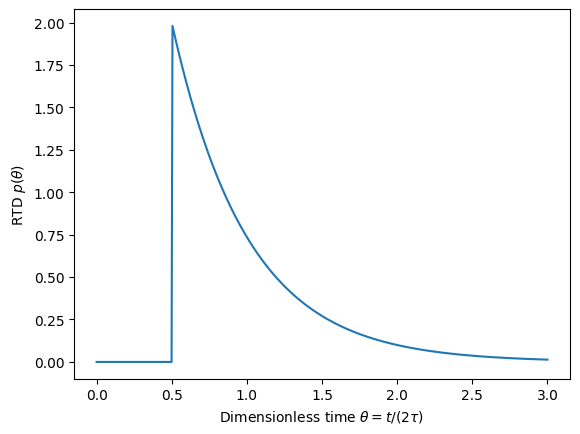

In [9]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, 3, 500)

p = np.zeros_like(theta)
mask = theta >= 0.5
p[mask] = 2.0 * np.exp(1.0 - 2.0 * theta[mask])

# plot
plt.plot(theta, p)
plt.xlabel(r"Dimensionless time $\theta = t/(2\tau)$")
plt.ylabel(r"RTD $p(\theta)$")
plt.show()

### Q1.2. Sketch the residence time distribution $p(\theta)$ you expect if the PFR is placed in front of the CSTR.

The sketch would be the same as Q1.1. because:
The overall RTD for units in series is the **convolution** of their
individual RTDs:

$
p_{\text{total}} = p_1 * p_2 .
$

Convolution is **commutative**, meaning:

$
p_1 * p_2 = p_2 * p_1.
$

So CSTR → PFR  and PFR → CSTR give the **same** residence time distribution.

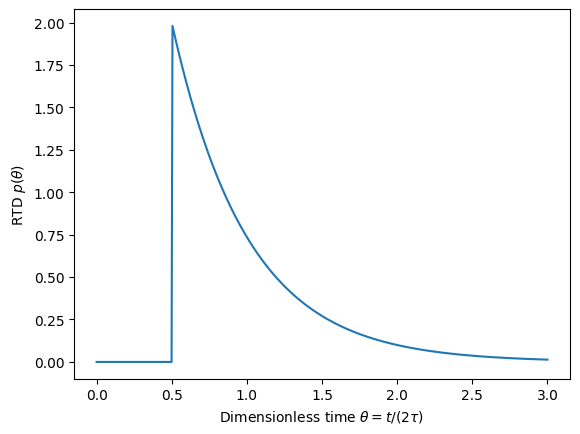

In [11]:
plt.plot(theta, p)
plt.xlabel(r"Dimensionless time $\theta = t/(2\tau)$")
plt.ylabel(r"RTD $p(\theta)$")
plt.show()

### Q1.3.Does the order matter? Why or why not?

The answer is in the above question

### Q1.4. Predict the conversion of A if the CSTR is placed in front of the PFR, assuming some volumetric flow rate $v$.

Define the space time for each unit:

$
\tau = \frac{V}{v}.
$

---

### CSTR first

Steady–state CSTR mole balance:

$
v(C_{A0} - C_{A1}) = Vk C_{A1}.
$

Solve for the CSTR outlet concentration \(C_{A1}\):

$
C_{A1} = \frac{C_{A0}}{1 + k\tau}.
$

---

### Then PFR

For a PFR of the same volume \(V\) and flow rate \(v\):

$
\frac{dC_A}{dV} = -\frac{k}{v} C_A.
$

Integrate from $V = 0 \to V$, with $C_A(0) = C_{A1}$:

$
C_{A2} = C_{A1} \exp\!\left(-\frac{kV}{v}\right)
       = C_{A1} e^{-k\tau}.
$

Substitute \(C_{A1}\):

$
C_{A2} = \frac{C_{A0}}{1 + k\tau} e^{-k\tau}.
$

---

### Overall conversion

$
\boxed{
X = 1 - \frac{C_{A2}}{C_{A0}}
  = 1 - \frac{e^{-k\tau}}{1 + k\tau}}
$

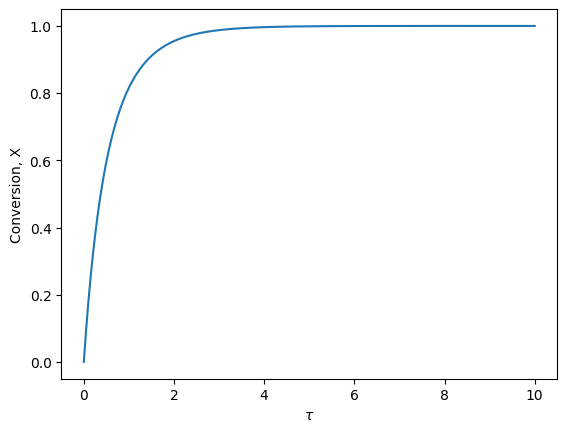

In [17]:
k = 1
tau = np.linspace(0, 10, 200)   # Damköhler number kV/v
X = 1 - np.exp(-k*tau) / (1 + k*tau)

plt.plot(tau, X)
plt.xlabel(r"$\tau$")
plt.ylabel("Conversion, X")
plt.show()

### Q1.5. Predict the conversion of A if the PFR is placed in front of the CSTR, assuming some volumetric flow rate $v$.

Similarly, get the PFR equation first and then the CSTR.

$
C_{A1}=C_{A0}e^{-k\tau}
$

$
C_{A2}=\frac{C_{A1}}{1+k\tau}=\frac{C_{A0}e^{-k\tau}}{1+k\tau}
$

Then $\boxed{X=1-\frac{e^{-k\tau}}{1+k\tau}}$, which gives the same result as the previous question.

### Q1.6. Does the order matter? Why or why not?

For a first–order reaction with equal reactor volumes and constant volumetric flowrate, the order does not matter.
CSTR → PFR and PFR → CSTR give exactly the same conversion.

# Q2. On the way in
The concentration $C_\text{A}$ of a reactant within a porous, spherical particle undergoing a first-order reaction is given by (in dimensionless units):

$$\psi(\lambda) = \frac{\sinh \lambda \Phi}{\lambda \sinh \Phi}$$

### Q2.1. Compute the diffusional flux through the surface of the particle,
$J_\text{A}=4\pi R^2 D_\text{A} \left (\frac{dC_\text{A}}{dr}\right)_{r=R}$.

We are given the dimensionless concentration profile in a porous spherical particle

$
\psi(\lambda) = \frac{C_A(r)}{C_{A,s}} = \frac{\sinh(\lambda\Phi)}{\lambda \sinh\Phi},
\qquad \lambda = \frac{r}{R}.
$

---

### 1. Differentiate $\psi(\lambda)$ with respect to $\lambda$

$
\frac{d\psi}{d\lambda}
= \frac{d}{d\lambda}\left(\frac{\sinh(\lambda\Phi)}{\lambda\sinh\Phi}\right)
= \frac{1}{\sinh\Phi}\,\frac{\lambda\Phi\cosh(\lambda\Phi)-\sinh(\lambda\Phi)}{\lambda^2}.
$

At the surface, $\lambda = 1$:

$
\left.\frac{d\psi}{d\lambda}\right|_{\lambda=1}
= \frac{\Phi\cosh\Phi-\sinh\Phi}{\sinh\Phi}
= \Phi\coth\Phi - 1.
$

---

### 2. Relate $\dfrac{dC_A}{dr}$ to $\dfrac{d\psi}{d\lambda}$

Because $\psi = C_A/C_{A,s}$ and $\lambda = r/R$,

$
\frac{d\psi}{dr} = \frac{1}{C_{A,s}}\frac{dC_A}{dr}
= \frac{d\psi}{d\lambda}\frac{d\lambda}{dr}
= \frac{1}{R}\frac{d\psi}{d\lambda}.
$

Thus, at $r=R$ (i.e. $\lambda = 1$):

$
\left.\frac{dC_A}{dr}\right|_{r=R}
= C_{A,s}\left.\frac{d\psi}{dr}\right|_{r=R}
= \frac{C_{A,s}}{R}\left(\Phi\coth\Phi - 1\right).
$

---

### 3. Diffusional flux through the particle surface

The flux is defined as

$
J_A = 4\pi R^2 D_A\left(\frac{dC_A}{dr}\right)_{r=R}.
$

Substitute the gradient:

$
J_A = 4\pi R^2 D_A \cdot \frac{C_{A,s}}{R}\left(\Phi\coth\Phi - 1\right)
    = 4\pi R D_A C_{A,s}\left(\Phi\coth\Phi - 1\right).
$

### Q2.2. Does the result look familiar?

$\Phi\coth\Phi - 1$  appears in the **effectiveness factor** for a first–order reaction in a porous spherical catalyst:

$
\eta = \frac{r_{pseudo}}{r_{homo}}
     = \frac{3}{\Phi}(\frac{1}{tanh\Phi} - \frac{1}{\Phi})
     = \frac{3}{\Phi^2}\left(\Phi\coth\Phi - 1\right)
$

So the flux we just derived is directly related to the classic effectiveness–factor
expression for a spherical particle.

# Q3. Bouncing off the walls
The isomerization of 1-hexene to 2-hexene is first order in 1-hexene and, at $150^\circ$C, has a rate constant of 0.14 s$^{-1}$. The reaction is carried out over a Rh catalyst supported on alumina. The alumina has a pore radius of 10 nm (small enough that diffusion in the particle is Knudsen). 

### Q3.1. What particle radius would allow the reactor to operate with an effectiveness of at least 0.7?

For a first–order reaction in a **spherical** porous catalyst, the
effectiveness factor is

$
\eta(\Phi) = \frac{3}{\Phi^2}\left(\Phi\coth\Phi - 1\right),
\qquad
\Phi = R_p\sqrt{\frac{k}{D_\text{eff}}}.
$

We want $\eta \ge 0.7$.

---

#### 1. Knudsen diffusivity in the pores

Pore radius: $r_p = 10 \text{ nm} = 1.0\times10^{-8}\,\text{m}$

Knudsen diffusivity:

$
D_K = \frac{2}{3} r_p
      \sqrt{\frac{8RT}{\pi M}}
$

For 1-hexene $C_6H_{12}$:
$M = 84\ \text{g mol}^{-1} = 0.084\ \text{kg mol}^{-1}$

$T = 150^\circ\text{C} = 423\ \text{K}$

$R = 8.314\ \text{J mol}^{-1}\text{K}^{-1}$

$
D_K \approx 2.2\times10^{-6}\ \text{m}^2\text{/s}.
$

We take $D_\text{eff}$.

---

#### 2. Find the Thiele modulus that gives $\eta = 0.7$

Solve

$
\eta(\Phi) = \frac{3}{\Phi^2}\left(\Phi\coth\Phi - 1\right) = 0.7
$

Numerically, this gives

$
\Phi \approx 2.77.
$

---

#### 3. Convert $\Phi$ to particle radius

Given $k = 0.14\ \text{s}^{-1}$,

$
\Phi = R_p\sqrt{\frac{k}{D_\text{eff}}}
\quad\Rightarrow\quad
R_p = \Phi\sqrt{\frac{D_\text{eff}}{k}}
    \approx 2.77 \sqrt{\frac{2.2\times10^{-6}}{0.14}}
    \approx 1.1\times10^{-2}\ \text{m}.
$

---

**Answer**

To have an effectiveness factor of at least 0.7, the particle radius
should be no larger than

$
\boxed{R_p \approx 1.1\times10^{-2}\ \text{m} \;\approx\; 1.1\ \text{cm} \; (11\ \text{mm}).}
$

Any smaller particle radius will give $\eta > 0.7$.

# Q4. What's the matter here?
The rate constant for the isothermal, first-order decomposition of cumene to benzene and propylene over a silica/alumina catalyst is measured to be $k_\text{obs} = 0.8~\text{cm}^3/(\text{g}_\text{cat}\text{s})$ at $250^\circ$C in a laboratory reactor:

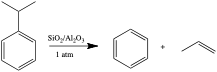

The reaction is run over spherical catalyst pellets with a radius of 0.25 cm and a density of 1.2 g$_\text{cat}$/cm$^3$.  Cumene has an effective diffusion constant $D_e = 1.0\times 10^{-3}~\text{cm}^2/\text{s}$ at this particular pore size and temperature.

### Q4.1. Is the rate constant a "true" value or is it limited by diffusion?  (Hint: Note that by definition the effectiveness $\eta = k_\text{obs}/k$ and that $\eta$ can also be written in terms of the Thiele modulus.  Solve the combination for $k$ and $\eta$.)

### 1. Effectiveness factor definition

$
\eta = \frac{k_{\text{obs}}}{k},
$
where k is the **true** intrinsic rate constant.

### 2. For a spherical particle with a first–order reaction,

$
\eta(\Phi) = \frac{3}{\Phi^2}\left(\Phi\coth\Phi - 1\right),
$
with Thiele modulus
$
\Phi^2 = \frac{k\,\rho_p\,R_p^2}{D_e}.
$

---

### Combine and solve for k

Substitute $\Phi^2$ into $\eta(\Phi)$ and use $\eta = k_{\text{obs}}/k$:

$
\frac{k_{\text{obs}}}{k}
= \frac{3}{\Phi^2}\left(\Phi\coth\Phi - 1\right),
\qquad
\Phi = R_p\sqrt{\frac{k\rho_p}{D_e}}.
$

This nonlinear equation is solved numerically for k.  
Doing so gives

$
k \approx 5.88\ \frac{\text{cm}^3}{\text{g}_{\text{cat}}\;\text{s}}.
$

Then

$
\eta = \frac{k_{\text{obs}}}{k}
= \frac{0.8}{5.88}
\approx 0.136.
$

The corresponding Thiele modulus is

$
\Phi = R_p\sqrt{\frac{k\rho_p}{D_e}}
\approx 21.
$

---


So **$k_{\text{obs}}$ is not the true kinetic rate constant; it is strongly reduced by internal diffusion limitations.**

### Q4.2. One way to adjust the catalyst effectiveness is by varying the pellet radius, $R$.  Plot $\eta$ vs $R$ on a log-log plot, assuming $D_e$ is constant. 

We know:
$
\eta(R) = \frac{3}{\Phi(R)^2}\Big(\Phi(R)\coth\Phi(R)-1\Big).
$

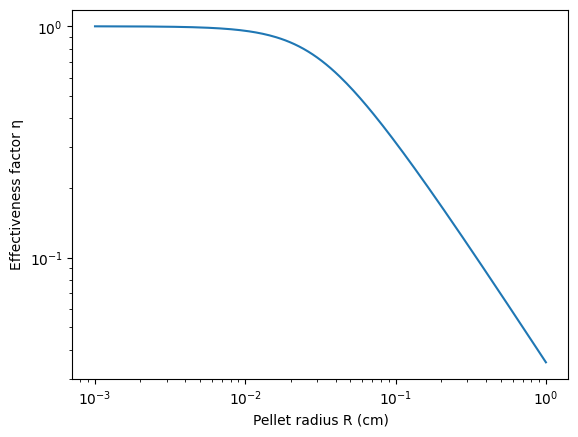

In [2]:
# parameters
k = 5.88          # cm^3/(g_cat s), intrinsic rate constant from Q4.1
rho_p = 1.2       # g_cat/cm^3
De = 1.0e-3       # cm^2/s

# radius range (cm): from 1e-3 to 1 cm, log-spaced
R = np.logspace(-3, 0, 200)

# Thiele modulus
Phi = R * np.sqrt(k * rho_p / De)

# effectiveness factor, eta(Phi) = 3/Phi^2 * (Phi*coth(Phi) - 1)
eta = (3.0 / Phi**2) * (Phi / np.tanh(Phi) - 1.0)   # coth(x) = 1/tanh(x)

# log-log plot
plt.loglog(R, eta)
plt.xlabel("Pellet radius R (cm)")
plt.ylabel("Effectiveness factor η")
plt.show()

### Q4.3. What pellet radius would be necessary to achieve an effectiveness of 0.9?  Why might you not want to use pellets of that size?

#### 1. Find the Thiele modulus for η = 0.9

Solve

$
\eta(\Phi) = \frac{3}{\Phi^2}\left(\Phi\coth\Phi - 1\right) = 0.9
$

Numerically this gives

$
\Phi \approx 1.32.
$

---

#### 2. Convert Φ to pellet radius R

$
\Phi = R\sqrt{\frac{k\rho_p}{D_e}}
\quad\Rightarrow\quad
R = \Phi \sqrt{\frac{D_e}{k\rho_p}}
$

$
R \approx 1.32 \sqrt{\frac{1.0\times10^{-3}}{5.88 \times 1.2}}
   \approx 1.6\times10^{-2}\ \text{cm}.
$

So

$
\boxed{R \approx 0.016\ \text{cm} \;\approx\; 0.16\ \text{mm}}
$

(compared to the original $R = 0.25\ \text{cm} = 2.5\ \text{mm}\$).

---

#### 3. Why you wouldn’t want pellets that small

There are several reasons. For example, to keep the same catalyst mass, you’d need an enormous number of tiny pellets, giving a very large pressure drop across the packed bed. Also there might be mechanical problems and handling issues. 

So, while $R \approx 0.16\ \text{mm}$ would give $\eta \approx 0.9$, using pellets that small would be impractical in most reactors.

### Q4.4.As a compromise, you decide to use pellets with a 0.10 cm radius.  The pellets pack into a 10 cm diameter pipe leaving a void fraction of 20% (i.e. occupying 80% of the space).  What length of packed pipe is necessary to react 500 kg/hr of 1 atm cumene gas at $250^\circ$C to 95% conversion?  You can assume the system pressure and density of the gas are constant as the reaction proceeds.

**Step 1 – Effectiveness factor at $R_p = 0.10\ \text{cm}$**  

$
\Phi = R_p\sqrt{\frac{k\rho_p}{D_e}}
      \approx 0.10\sqrt{\frac{5.88\times1.2}{10^{-3}}}
      \approx 8.75
$

$
\eta = \frac{3}{\Phi^2}\left(\Phi\coth\Phi - 1\right)
     \approx 0.315.
$

---

**Step 2 – Effective first-order rate constant in the bed**

Rate per mass of catalyst:

$
-r_A' = \eta k C_A.
$

Bulk (bed) density of catalyst:

$
\rho_b = (1-\varepsilon)\rho_p = 0.80 \times 1.2 = 0.96\ \text{g}_\text{cat}/\text{cm}^3.
$

Rate per reactor volume:

$
-r_A = \rho_b(-r_A') = \rho_b\eta k C_A
     = k_{\text{eff}} C_A,
$
with

$
k_{\text{eff}} = \rho_b\eta k
               = 0.96 \times 0.315 \times 5.88
               \approx 1.78\ \text{s}^{-1}.
$

So the packed bed behaves like a gas-phase PFR with a first-order rate
constant $k_{\text{eff}}$.

---

**Step 3 – Volumetric flow of the gas**

Feed: $500\ \text{kg/h}$ cumene. Molar mass of cumene $C_9H_12$:

$
M = 120\ \text{g/mol}.
$

$
\dot n_A = \frac{500\,000\ \text{g/h}}{120\ \text{g/mol}}
        \approx 4.17\times10^3\ \text{mol/h}
        \approx 1.16\ \text{mol/s}.
$

At 1 atm and $T = 250^\circ\text{C} = 523\ \text{K}$,

$
\dot V_0 = \dot n_A \frac{RT}{P}
         = (1.16)\frac{82.06\ \text{cm}^3\text{atm/mol K}\times 523\ \text{K}}{1\ \text{atm}}
         \approx 4.97\times10^4\ \text{cm}^3/\text{s}.
$

---

**Step 4 – Required bed volume for 95% conversion**

For a first-order PFR with constant density,

$
X = 0.95,
\qquad
V = \frac{\dot V_0}{k_{\text{eff}}}
    \ln\left(\frac{1}{1-X}\right).
$

$
V = \frac{4.97\times10^4}{1.78}
    \ln\left(\frac{1}{0.05}\right)
  \approx 8.38\times10^4\ \text{cm}^3
  \approx 84\ \text{L}.
$

This is the **total bed volume** (void + pellets).

---

**Step 5 – Convert volume to pipe length**

Pipe diameter: $10\ \text{cm}$ → radius $R_\text{pipe} = 5\ \text{cm}$.

Cross-sectional area:

$
A = \pi R_\text{pipe}^2 = \pi (5\ \text{cm})^2 \approx 78.5\ \text{cm}^2.
$

Bed length:

$
L = \frac{V}{A}
  = \frac{8.38\times10^4\ \text{cm}^3}{78.5\ \text{cm}^2}
  \approx 1.07\times10^3\ \text{cm}
  \boxed{\approx 10.7\ \text{m}}
$

### Q4.5. Plot the rate of cumene consumption as a function of radial distance from the pellet center ($r_\text{max} = kC_\text{cumene}(r))$ for (a) a pellet at the reactor entrance (i.e. where the cumene pressure is 1 atm) and (b) for a pellet at the reactor exit.

For a first–order reaction in a spherical pellet, the internal concentration
profile is

$
\frac{C_\text{cumene}(r)}{C_s}
= \psi(\lambda)
= \frac{\sinh(\lambda\Phi)}{\lambda\sinh\Phi},
\qquad \lambda = \frac{r}{R},
$

where R is the pellet radius and $\Phi$ is the Thiele modulus.

The **local intrinsic rate of cumene consumption** (per mass of catalyst) is

$
r_{\max}(r) = k\,C_\text{cumene}(r)
            = k\,C_s\,\psi\!\left(\frac{r}{R}\right).
$

- At the **reactor entrance**, the surface concentration corresponds to
  the feed: $C_{s,\text{in}} = C_0$ (1 atm cumene).
- At the **reactor exit**, we have 95 % conversion, so
  $C_{s,\text{out}} = 0.05\,C_0$.

Thus

$
r_{\max,\text{in}}(r)  = k\,C_0\,\psi\!\left(\frac{r}{R}\right),
\qquad
r_{\max,\text{out}}(r) = k\,(0.05\,C_0)\,\psi\!\left(\frac{r}{R}\right).
$

Below is Python code for a Jupyter notebook that plots these rate profiles
vs. radial position for the pellets used in Q4.4 $R = 0.10\ \text{cm}$,
$\Phi \approx 8.75$.

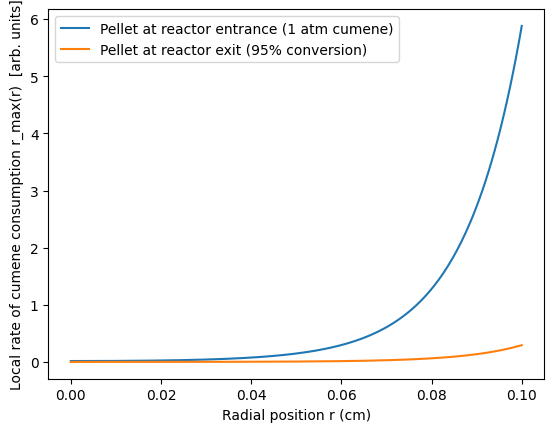

In [19]:
# parameters
R = 0.10                 # pellet radius [cm]
Phi = 8.75               # Thiele modulus for R = 0.10 cm (from Q4.4)
k = 5.88                 # intrinsic k [cm^3/(g_cat s)] – only a scale factor
C0 = 1.0                 # arbitrary inlet concentration units

# dimensionless radius and dimensional radius
lam = np.linspace(1e-4, 1.0, 300)      # λ = r/R (avoid 0 exactly to dodge division by zero)
r = lam * R                            # [cm]

# dimensionless concentration profile ψ(λ)
psi = np.sinh(Phi * lam) / (lam * np.sinh(Phi))

# local rates (per mass of catalyst, up to a constant factor)
r_in   = k * C0       * psi           # pellet at reactor entrance (1 atm cumene)
r_out  = k * 0.05*C0 * psi           # pellet at reactor exit (5% of inlet conc.)

# plot
plt.plot(r, r_in,  label="Pellet at reactor entrance (1 atm cumene)")
plt.plot(r, r_out, label="Pellet at reactor exit (95% conversion)")

plt.xlabel("Radial position r (cm)")
plt.ylabel("Local rate of cumene consumption r_max(r)  [arb. units]")
plt.legend()
plt.show()

### Q4.6. At steady state, do you expect the concentration of benzene to increase or decrease with radial distance from the particle center?  Why?

- **Reactants (cumene):** diffuse inward → consumption makes them **lowest at the center**.
- **Products (benzene):** formed inside → must diffuse outward → highest concentration at **center**, lowest at surface.

Therefore, the benzene concentration **decreases with radial distance** from the center to the surface.

### Q4.7. A colleague points out that the external mass transfer resistance could also limit the pellet effectiveness.  Since the pellets are small and the flow reasonably slow, a plausible estimate of the external mass transfer coefficient, $k_m$, is $0.05/R$ cm$^2$/s.  Assuming the same $D_e$, do you expect external mass transfer to reduce the effectiveness?

### 1. Compare external vs. internal resistance (mass‐transfer Biot number)

$
\mathrm{Bi}_m = \frac{k_m R}{D_e}.
$

Plug in:

$
\mathrm{Bi}_m
= \frac{(0.5\ \text{cm/s})(0.10\ \text{cm})}{1.0\times10^{-3}\ \text{cm}^2/\text{s}}
= \frac{0.05}{1.0\times10^{-3}}
= 50.
$

In the lecture note:
- If **Bi\_m is large** → limited by what's going on inside the particle
- If **Bi\_m is small** → limited by mass transfer to particle

Because \(\mathrm{Bi}_m\) is large:

- **No, external mass transfer will not significantly reduce the effectiveness.**
- The pellet is already limited mainly by **internal diffusion and reaction**.